# 🛴 킥보드 불법 주정차 탐지 with Grounding DINO
- **횡단보도 앞의 킥보드** 탐지
- **쓰러진 킥보드** 탐지

In [1]:
# 패키지 설치
!pip install -q transformers torch torchvision pillow requests
print('✅ 설치 완료')

✅ 설치 완료


In [2]:
# 모델 로드
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import torch

MODEL_ID = 'IDEA-Research/grounding-dino-base'
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'사용 장치: {device}')

processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForZeroShotObjectDetection.from_pretrained(MODEL_ID).to(device)
print('✅ 모델 로드 완료')

사용 장치: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/1206 [00:00<?, ?it/s]

✅ 모델 로드 완료


In [32]:
# 프롬프트 적용 객체인식 함수 작성
from PIL import Image, ImageDraw, ImageFont
import torch
import torchvision.ops as ops

TEXT_PROMPTS = [
    'kickboard parked in front of crosswalk. electric scooter blocking pedestrian crossing.',
    'kickboard fallen on its side on the ground. electric scooter lying horizontally on sidewalk.',
    'kickboard on yellow tactile paving. electric scooter parked on braille blocks.'
]

LABELS = [
    'Violation',
    'Violation',
    'Violation'
]

COLORS = [
    '#ff3b30',
    '#ff3b30',
    '#ff3b30'
]

BOX_THRESHOLD = 0.40  # confidence가 0.4 넘는 값만 표시
IOU_THRESHOLD = 0.40  # IoU 0.4보다 크면 중복으로 판단, NMS만 남김

def detect_kickboard(image: Image.Image):
    draw_image = image.copy()
    draw = ImageDraw.Draw(draw_image)
    font = ImageFont.load_default()

    # 1. 모든 프롬프트의 결과를 한곳에 모으기 위한 리스트 초기화
    all_boxes = []
    all_scores = []
    all_labels = []
    all_colors = []

    # 각 프롬프트 순회하며 탐지 수행
    for prompt, label, color in zip(TEXT_PROMPTS, LABELS, COLORS):
        inputs = processor(images=image, text=prompt, return_tensors='pt').to(device)

        with torch.no_grad():
            outputs = model(**inputs)

        target_sizes = torch.tensor([image.size[::-1]])
        results = processor.post_process_grounded_object_detection(
            outputs, inputs.input_ids, target_sizes=target_sizes,
        )[0]

        for box, score in zip(results['boxes'], results['scores']):
            if score < BOX_THRESHOLD:
                continue

            # 기준을 만족하는 결과를 리스트에 축적
            all_boxes.append(box)
            all_scores.append(score)
            all_labels.append(label)
            all_colors.append(color)

    # 2. 탐지된 객체가 있을 경우에만 NMS 진행
    if len(all_boxes) > 0:
        # 리스트를 텐서 형태로 변환
        boxes_tensor = torch.stack(all_boxes).to(device)
        scores_tensor = torch.stack(all_scores).to(device)

        # torchvision의 NMS 연산 수행 -> 살아남은 박스들의 인덱스 반환
        keep_indices = ops.nms(boxes_tensor, scores_tensor, IOU_THRESHOLD)

        print(f"총 {len(all_boxes)}개 탐지 중 NMS 적용 후 {len(keep_indices)}개 유지")

        # 3. NMS를 통과한 최종 박스들만 이미지에 그리기
        for idx in keep_indices:
            box = boxes_tensor[idx].cpu()
            score = scores_tensor[idx].cpu().item()
            label = all_labels[idx]
            color = all_colors[idx]

            x0, y0, x1, y1 = box.tolist()
            text = f'{label} {score:.2f}'

            text_fill = 'white'

            # 텍스트 크기 계산
            text_bbox = draw.textbbox((0, 0), text, font=font)
            text_width = text_bbox[2] - text_bbox[0]
            text_height = text_bbox[3] - text_bbox[1]

            padding = 4

            # 라벨 위치
            text_x = x0
            text_y = max(0, y0 - text_height - padding * 2)

            # 배경 박스
            background_box = [
                text_x,
                text_y,
                text_x + text_width + padding * 2,
                text_y + text_height + padding * 2
            ]

            # draw
            draw.rectangle(background_box, fill=color)
            draw.rectangle([x0, y0, x1, y1], outline=color, width=4)

            draw.text(
                (text_x + padding, text_y + padding),
                text,
                fill=text_fill,
                font=font
            )

            print(f'[{label}] score: {score:.3f} | box: ({int(x0)}, {int(y0)}, {int(x1)}, {int(y1)})')
    else:
        print('No kickboard detected')

    return draw_image

print('✅ Done')

✅ Done


Saving abnormal_not_detected.jpeg to abnormal_not_detected (3).jpeg
Saving abnormal_not_detected2.jpeg to abnormal_not_detected2 (3).jpeg
Saving prevent_blind5.jpg to prevent_blind5 (10).jpg

📷 파일: abnormal_not_detected (3).jpeg
총 2개 탐지 중 NMS 적용 후 1개 유지
[Violation] score: 0.551 | box: (273, 216, 300, 294)


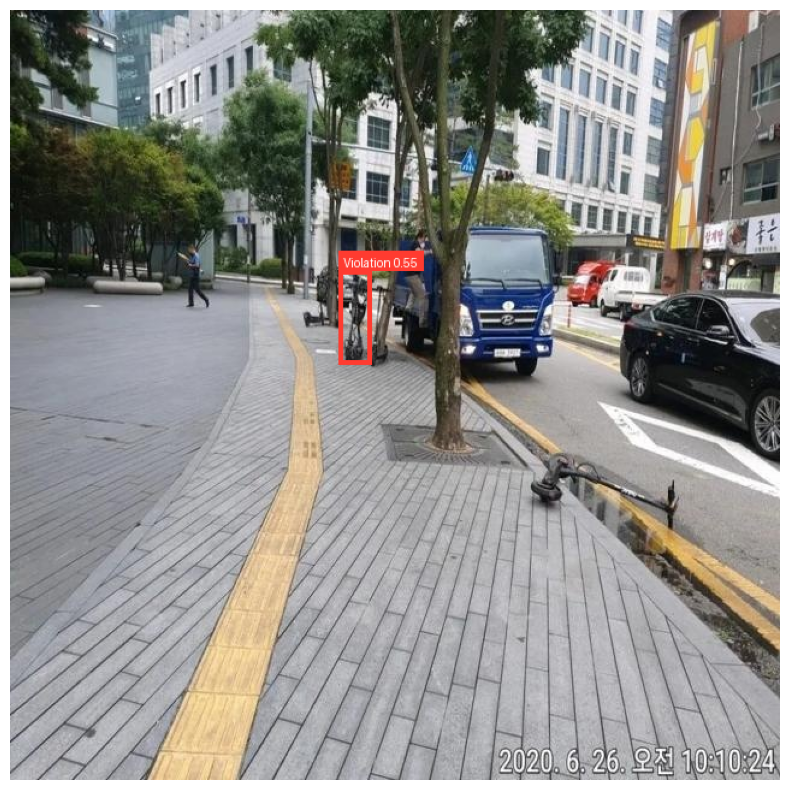

💾 결과 저장: result_abnormal_not_detected (3).jpeg

📷 파일: abnormal_not_detected2 (3).jpeg
총 4개 탐지 중 NMS 적용 후 2개 유지
[Violation] score: 0.753 | box: (242, 364, 324, 476)
[Violation] score: 0.432 | box: (454, 341, 625, 471)


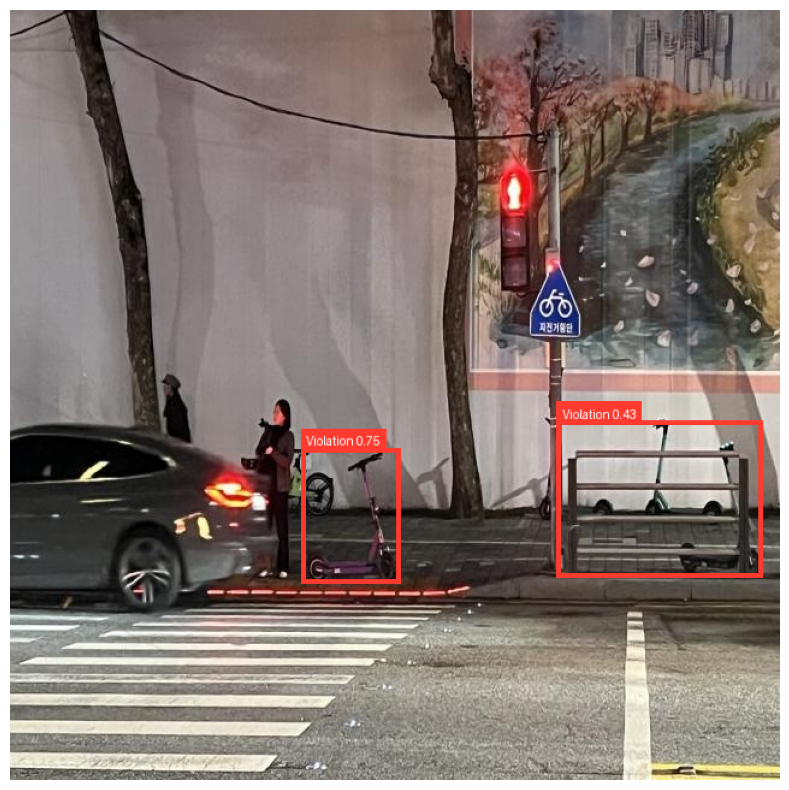

💾 결과 저장: result_abnormal_not_detected2 (3).jpeg

📷 파일: prevent_blind5 (10).jpg
총 3개 탐지 중 NMS 적용 후 1개 유지
[Violation] score: 0.727 | box: (87, 96, 631, 951)


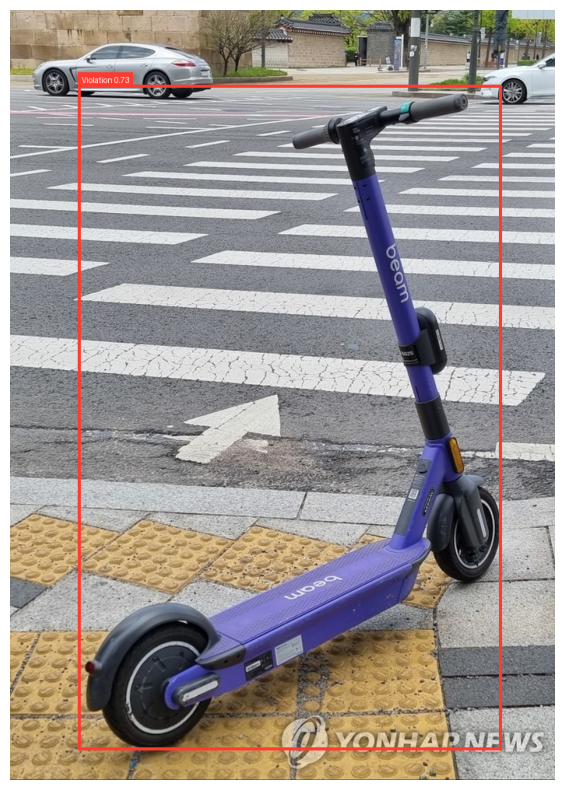

💾 결과 저장: result_prevent_blind5 (10).jpg


In [34]:
# 이미지 탐지 (Colab 파일 업로드 사용)
from google.colab import files

uploaded = files.upload()

for filename, data in uploaded.items():
    print(f'\n📷 파일: {filename}')
    image = Image.open(BytesIO(data)).convert('RGB')
    result_image = detect_kickboard(image)

    plt.figure(figsize=(14, 8))
    plt.imshow(result_image)
    plt.axis('off')
    plt.tight_layout()
    plt.show()

    # 결과 저장
    out_path = f'result_{filename}'
    result_image.save(out_path)
    print(f'💾 결과 저장: {out_path}')